# Parfüm Markası Sınıflandırması: Koku Notalarından Marka Tahmini

Fragrantica verisindeki en popüler 10 markanın parfümlerini; koku notaları (Top / Middle / Base), cinsiyet, puan ve yıl bilgisinden tahmin etmeye çalışıyorum.

**Akış:** veri hazırlama → keşifsel veri analizi → boyut indirgeme ve görselleştirme (SVD, t-SNE, UMAP) → veri bölme → özellik seçimi (keşifsel) → modelleme (sızıntısız pipeline + GridSearchCV) → ablation → sonuçlar ve sınırlılıklar.

**Veri:** Kaggle'daki [Fragrantica.com Fragrance Dataset](https://www.kaggle.com/datasets/olgagmiufana1/fragrantica-com-fragrance-dataset) içindeki `fra_cleaned.csv`.

**Not:** Marka tahmini pratik bir uygulamadan çok, koku notalarının markaya özgü bir imza taşıyıp taşımadığını ölçen bir vekil (proxy) görevdir.

In [1]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", message="n_jobs value")

import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, silhouette_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TOP_N_BRANDS = 10
GOLD = "#D4AF37"  # estetik renk: yalnızca tek renkli grafiklerde

# Veri yolu: Colab'da Drive'dan, yerelde / GitHub klonunda data/ klasöründen
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_PATH = "/content/drive/MyDrive/fra_cleaned.csv"
except ImportError:
    DATA_PATH = "data/fra_cleaned.csv"

sns.set_theme(style="whitegrid")

## 1. Veri yükleme ve hazırlık

- Veri en sık geçen 10 markayla sınırlandırılır.
- Metin boşlukları boş string ile doldurulur (öğrenilen bir parametre içermediği için bölmeden önce yapılabilir).
- Sayısal boşluklar (`Rating Value`, `Rating Count`) **bölmeden sonra, pipeline içinde** eğitim verisinin medyanıyla doldurulur; böylece test verisinden bilgi sızmaz.
- `Year` eksik olan satırlar medyanla doldurmak yerine düşürülür (yapay bir kümelenmeyi önlemek için).

In [2]:
data = pd.read_csv(DATA_PATH, sep=";", encoding="latin-1")
print(f"Ham veri: {data.shape[0]} satır, {data.shape[1]} sütun")

top_brands = data["Brand"].value_counts().head(TOP_N_BRANDS).index.tolist()
df = data[data["Brand"].isin(top_brands)].copy()

# Ondalık ayracı virgül olan metni sayıya çevir (dtype'a bakmadan, her pandas sürümünde çalışır)
df["Rating Value"] = pd.to_numeric(df["Rating Value"].astype(str).str.replace(",", "."), errors="coerce")

print("\nEksik değer sayıları (seçilen markalar):")
print(df[["Top", "Middle", "Base", "Gender", "Rating Value", "Rating Count", "Year"]].isna().sum())

for col in ["Top", "Middle", "Base"]:
    df[col] = df[col].fillna("")
df["Notes"] = (df["Top"] + " " + df["Middle"] + " " + df["Base"]).str.lower().str.strip()

n_before = len(df)
df = df.dropna(subset=["Year"]).reset_index(drop=True)
print(f"\nYear eksikliği nedeniyle {n_before - len(df)} satır çıkarıldı. Nihai satır sayısı: {len(df)}")

brand_order = df["Brand"].value_counts().index.tolist()
brand_colors = dict(zip(brand_order, sns.color_palette("tab10", len(brand_order))))

Ham veri: 24063 satır, 18 sütun

Eksik değer sayıları (seçilen markalar):
Top               0
Middle            0
Base              0
Gender            0
Rating Value      0
Rating Count      0
Year            111
dtype: int64

Year eksikliği nedeniyle 111 satır çıkarıldı. Nihai satır sayısı: 3083


## 2. Keşifsel veri analizi

Brand
avon                  17.8 %
zara                  16.4 %
o-boticario           11.3 %
guerlain              11.1 %
natura                 9.5 %
oriflame               9.0 %
yves-saint-laurent     6.4 %
givenchy               6.3 %
dior                   6.2 %
giorgio-armani         6.0 %
Name: count, dtype: str

En büyük sınıfın oranı (çoğunluk sınıfı baseline'ı): 0.178


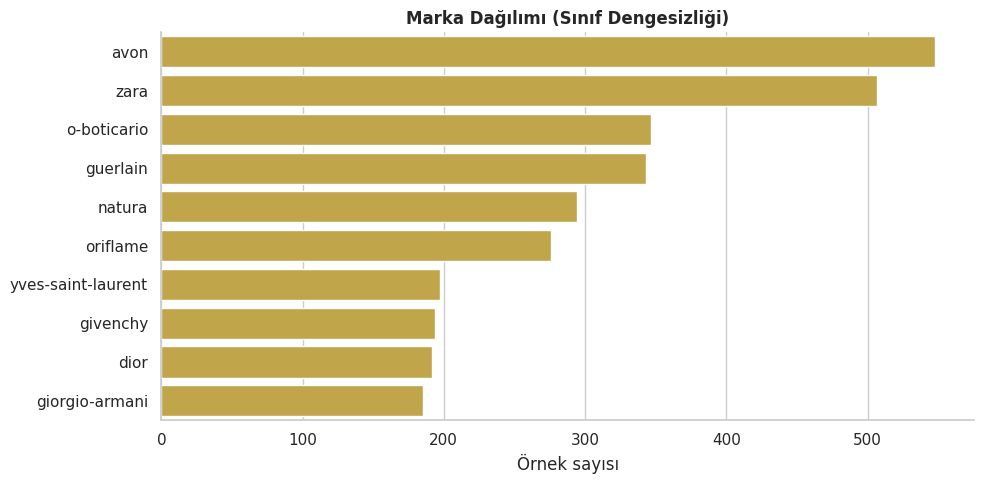

In [3]:
counts = df["Brand"].value_counts()
print((counts / len(df) * 100).round(1).astype(str) + " %")
print(f"\nEn büyük sınıfın oranı (çoğunluk sınıfı baseline'ı): {counts.iloc[0] / len(df):.3f}")

plt.figure(figsize=(10, 5))
sns.countplot(y="Brand", data=df, order=brand_order, color=GOLD)
plt.title("Marka Dağılımı (Sınıf Dengesizliği)", fontweight="bold")
plt.xlabel("Örnek sayısı")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

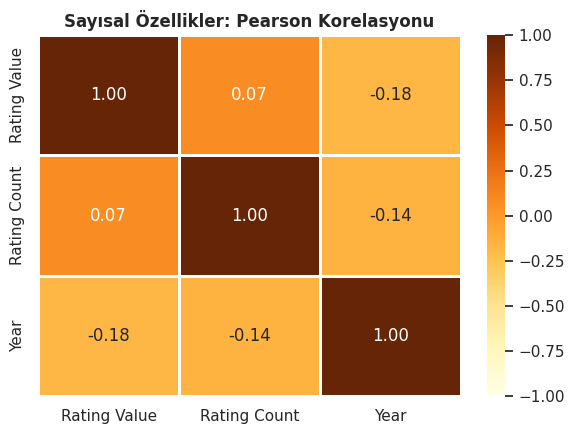

,count,mean,std,min,25%,50%,75%,max
Rating Value,3083.0,3.987804,0.282697,2.69,3.82,4.0,4.18,4.81
Rating Count,3083.0,682.191048,1868.924115,26.00,69.00,172.0,474.50,25669.00
Year,3083.0,2012.719429,12.844933,1872.00,2010.00,2016.0,2020.00,2024.00


In [4]:
num_raw = ["Rating Value", "Rating Count", "Year"]

plt.figure(figsize=(6, 4.5))
sns.heatmap(df[num_raw].corr(), annot=True, cmap="YlOrBr", fmt=".2f", vmin=-1, vmax=1,
            linewidths=1, linecolor="white")
plt.title("Sayısal Özellikler: Pearson Korelasyonu", fontweight="bold")
plt.tight_layout()
plt.show()

display(df[num_raw].describe().T)

`Rating Count` güçlü biçimde sağa çarpık (medyan ≪ ortalama < maksimum) ve `Year` içinde 1900 öncesine uzanan uç değerler var. Bunlar mesafe tabanlı modelleri (k-NN, lojistik regresyon) bozabileceği için modelleme girdisinde `Rating Count` log dönüşümüyle, `Year` ise alt sınırdan kırpılarak kullanılır. İki işlem de veriden parametre öğrenmediği için bölmeden önce yapılabilir.

In [5]:
YEAR_FLOOR = 1950
print(f"{YEAR_FLOOR} öncesi {(df['Year'] < YEAR_FLOOR).sum()} kayıt {YEAR_FLOOR} değerine kırpıldı.")
df["Year"] = df["Year"].clip(lower=YEAR_FLOOR)
df["Log Rating Count"] = np.log1p(df["Rating Count"])

num_cols = ["Rating Value", "Log Rating Count", "Year"]
cat_cols = ["Gender"]
text_col = "Notes"

# Çoklu doğrusallık kontrolü (yalnızca raporlama; bu 3 özellik için anlamlı bir eleme gerektirmiyorsa düşürme yapılmaz)
corr = df[num_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
high_corr = [c for c in upper.columns if (upper[c] > 0.90).any()]
print("|r| > 0.90 olan özellik:", high_corr if high_corr else "yok")

1950 öncesi 26 kayıt 1950 değerine kırpıldı.
|r| > 0.90 olan özellik: yok


## 3. Boyut indirgeme ve görselleştirme

Bu bölüm **yalnızca keşif amaçlıdır**: TF-IDF tüm veriye fit edilir (denetimsiz, etiket kullanılmaz) ve sonuçlar modellemede kullanılmaz. Modelleme bölümündeki TF-IDF yalnızca eğitim verisine fit edilir.

`TruncatedSVD`, seyrek TF-IDF matrisine uygulanır. PCA'dan farkı veriyi ortalamaya göre **merkezlememesidir** (merkezleme seyrek matrisi yoğunlaştırırdı); bu yüzden sonuçlar PCA ile birebir aynı değildir.

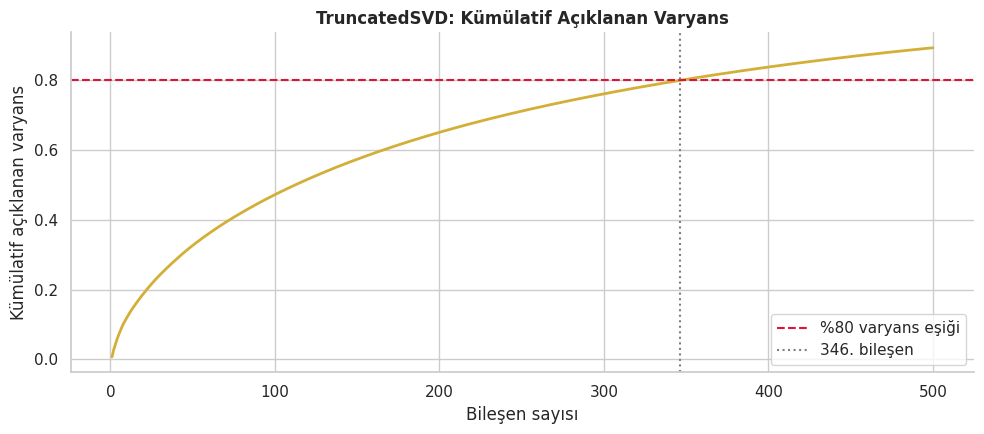

%80 varyansa ulaşmak için gereken bileşen sayısı: 346
100 bileşenin açıkladığı varyans: 0.47


In [6]:
tfidf_vis = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_tfidf = tfidf_vis.fit_transform(df["Notes"])

svd_full = TruncatedSVD(n_components=500, random_state=RANDOM_STATE).fit(X_tfidf)
cum_var = np.cumsum(svd_full.explained_variance_ratio_)
n80 = int(np.argmax(cum_var >= 0.80)) + 1 if (cum_var >= 0.80).any() else None

plt.figure(figsize=(10, 4.5))
plt.plot(range(1, 501), cum_var, color=GOLD, linewidth=2)
plt.axhline(0.80, color="crimson", linestyle="--", label="%80 varyans eşiği")
if n80:
    plt.axvline(n80, color="gray", linestyle=":", label=f"{n80}. bileşen")
plt.title("TruncatedSVD: Kümülatif Açıklanan Varyans", fontweight="bold")
plt.xlabel("Bileşen sayısı")
plt.ylabel("Kümülatif açıklanan varyans")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

print(f"%80 varyansa ulaşmak için gereken bileşen sayısı: {n80}")
print(f"100 bileşenin açıkladığı varyans: {cum_var[99]:.2f}")

Eğri yumuşak olduğu için belirgin bir "dirsek" yoktur; bu nedenle kriter olarak %80 kümülatif varyans eşiği kullanıldı. t-SNE ve UMAP için girdi olarak 100 bileşen alınır: bu, hız ve gürültü azaltma için yaygın bir ön adımdır, ancak yukarıda yazdırılan oranda varyans korunur, yani bir miktar bilgi kaybı vardır.

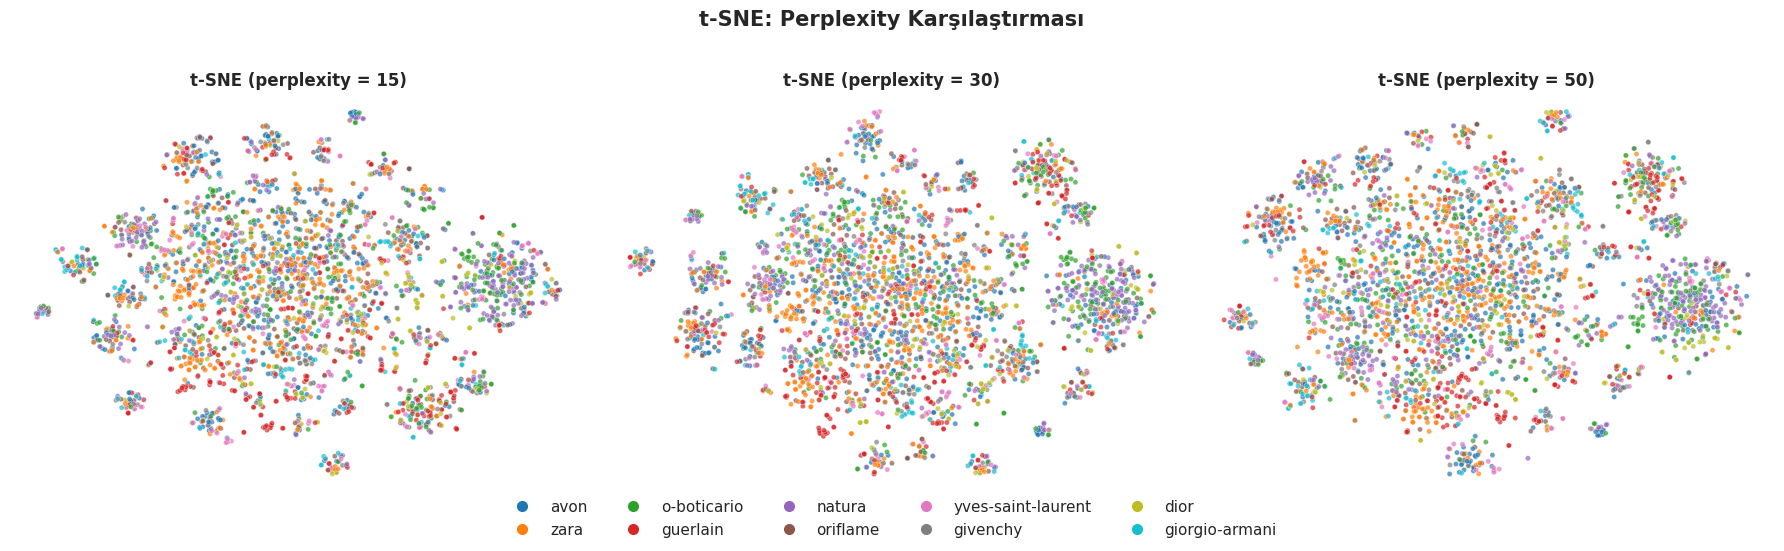

In [7]:
X_svd100 = TruncatedSVD(n_components=100, random_state=RANDOM_STATE).fit_transform(X_tfidf)
brands = df["Brand"].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, perp in zip(axes, [15, 30, 50]):
    emb = TSNE(n_components=2, perplexity=perp, init="pca", random_state=RANDOM_STATE).fit_transform(X_svd100)
    sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=brands, palette=brand_colors, s=14, alpha=0.7,
                    legend=False, ax=ax)
    ax.set_title(f"t-SNE (perplexity = {perp})", fontweight="bold")
    ax.axis("off")

handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=c, label=b, markersize=7)
           for b, c in brand_colors.items()]
fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False)
plt.suptitle("t-SNE: Perplexity Karşılaştırması", fontweight="bold", fontsize=15)
plt.tight_layout(rect=[0, 0.07, 1, 0.97])
plt.show()

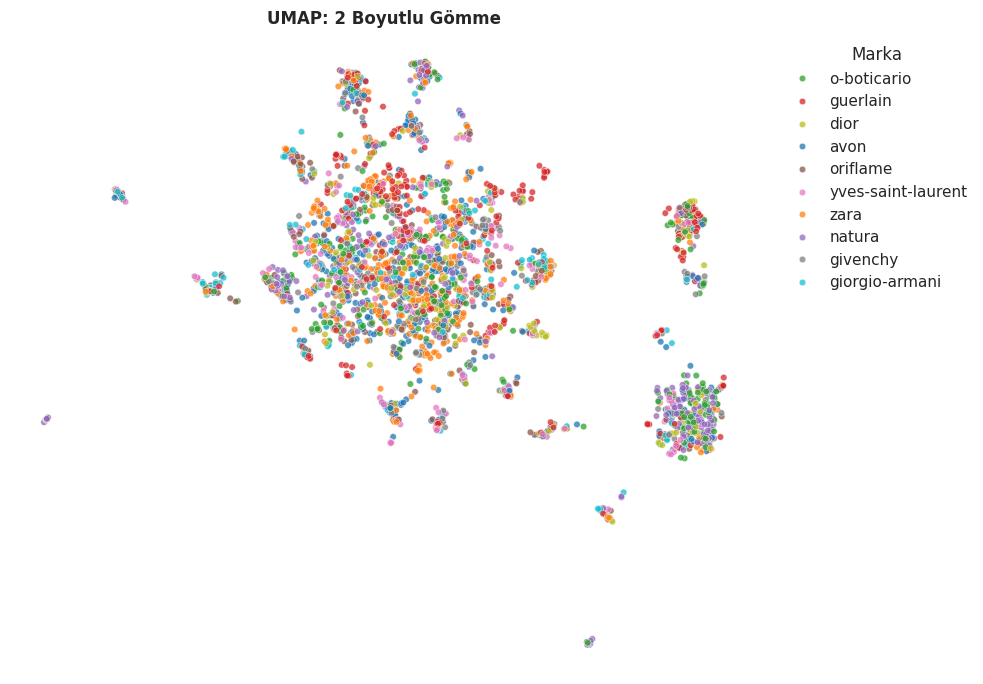

Marka etiketlerine göre silhouette skoru (UMAP uzayı): -0.124


In [8]:
X_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                   random_state=RANDOM_STATE).fit_transform(X_svd100)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=brands, palette=brand_colors, s=22, alpha=0.75)
plt.title("UMAP: 2 Boyutlu Gömme", fontweight="bold")
plt.legend(title="Marka", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.axis("off")
plt.tight_layout()
plt.show()

sil = silhouette_score(X_umap, brands)
print(f"Marka etiketlerine göre silhouette skoru (UMAP uzayı): {sil:.3f}")

**Yorum.** Silhouette skoru −1 ile 1 arasındadır; 0'a yakın veya negatif değerler etiketlerin uzayda ayrışmadığını gösterir. Yukarıdaki skor ve grafikler birlikte okunmalıdır: büyük, yoğun bir merkezi bulutun yanında bazı küçük ayrık kümeler görülür (bu kümelerin çoğu birden fazla markanın karışımıdır; örneğin sağ alttaki kümede ağırlıklı olarak O Boticário ve Natura birlikte yer alır), ancak markalar genel olarak birbirinden net biçimde ayrışmaz. Bu, markaların benzer popüler notaları (vanilya, misk, gül vb.) paylaştığına işaret eder ve yalnızca metin verisiyle marka ayırt etmenin zor bir görev olduğunu düşündürür. Bu bir kanıt değil, bir işarettir; asıl test aşağıdaki denetimli modelleme sonuçlarıdır.

t-SNE'de perplexity arttıkça global yapı daha belirgin hale gelir. Markaların üç ayarda da net ayrışmaması, ayrışmama durumunun hiperparametre seçiminden değil verinin kendisinden kaynaklandığını gösterir.

## 4. Eğitim / test bölmesi ve ön işleme

Veri **önce** bölünür; ölçekleme, imputation, one-hot ve TF-IDF yalnızca eğitim verisinden öğrenilir. Test seti model seçiminde kullanılmaz.

In [9]:
X = df[["Notes", "Gender", "Rating Value", "Log Rating Count", "Year"]]
y = df["Brand"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Eğitim: {len(X_train)} | Test: {len(X_test)}")


def build_preprocessor(use_meta=True):
    """Metin her zaman dahil; use_meta=False ablation için sayısal ve kategorik özellikleri çıkarır."""
    transformers = [("text", TfidfVectorizer(max_features=500, ngram_range=(1, 2)), text_col)]
    if use_meta:
        transformers = [
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                              ("sc", StandardScaler())]), num_cols),
            ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="unknown")),
                              ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
        ] + transformers
    return ColumnTransformer(transformers)


def make_pipeline(clf, use_meta=True, memory=None):
    """Ön işleme + RFE (50 özellik) + sınıflandırıcı. Hepsi CV içinde yeniden fit edilir."""
    rfe = RFE(RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=1),
              n_features_to_select=50, step=0.1)
    return Pipeline([("prep", build_preprocessor(use_meta)), ("rfe", rfe), ("clf", clf)], memory=memory)

Eğitim: 2466 | Test: 617


## 5. Özellik seçimi (keşifsel)

ANOVA F-testi (filtre) ve Random Forest önem skorları (embedded) **yalnızca eğitim verisi üzerinde** hesaplanır ve hangi özelliklerin ayırt edici olduğunu görmek için kullanılır. Nihai modeldeki özellik seçimi (RFE), aşağıdaki pipeline'ın içinde ve her CV katmanında ayrıca yapılır.

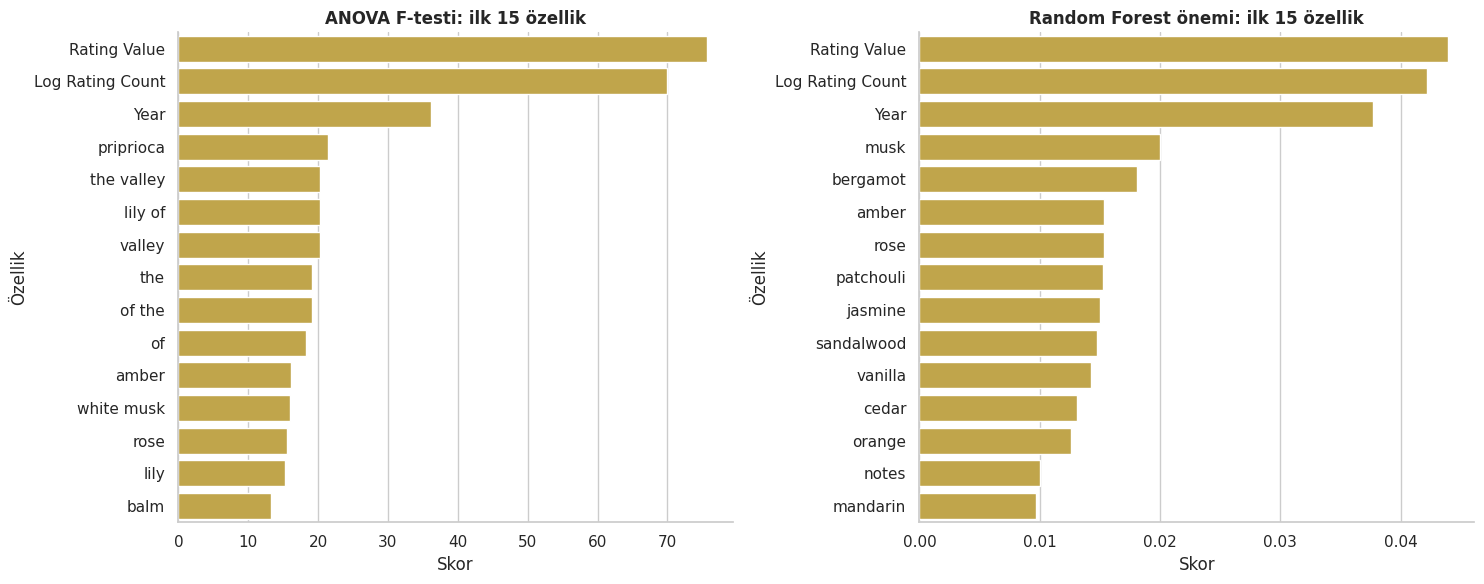

In [10]:
prep_explore = build_preprocessor().fit(X_train)
Xtr = prep_explore.transform(X_train)
feat_names = [n.split("__", 1)[1] for n in prep_explore.get_feature_names_out()]

f_scores, _ = f_classif(Xtr, y_train)
anova_top = (pd.DataFrame({"Özellik": feat_names, "Skor": np.nan_to_num(f_scores)})
             .sort_values("Skor", ascending=False).head(15))

rf_explore = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                    random_state=RANDOM_STATE, n_jobs=-1).fit(Xtr, y_train)
rf_top = (pd.DataFrame({"Özellik": feat_names, "Skor": rf_explore.feature_importances_})
          .sort_values("Skor", ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x="Skor", y="Özellik", data=anova_top, ax=axes[0], color=GOLD)
axes[0].set_title("ANOVA F-testi: ilk 15 özellik", fontweight="bold")
sns.barplot(x="Skor", y="Özellik", data=rf_top, ax=axes[1], color=GOLD)
axes[1].set_title("Random Forest önemi: ilk 15 özellik", fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

**Yorum.** Her iki yöntemde de en yüksek skorlu üç özellik koku notaları değil, `Rating Value`, `Log Rating Count` ve `Year`. Bu, markaların puan, popülerlik ve çıkış yılı bakımından birbirinden ayrıştığını gösterir ve ablation bölümündeki sonuçla birlikte okunmalıdır. Not tarafında ise `priprioca` gibi belirli marka serilerine özgü notalar öne çıkıyor. Ayrıca `the`, `of`, `of the` gibi anlamsız n-gram'lar da listede: `lily-of-the-valley` gibi çok kelimeli notalar varsayılan tokenizer ile kelimelere bölünüyor. Notaları virgülle ayrılmış tek birim olarak ele almak (özel bir tokenizer) bu gürültüyü azaltabilir; bu fikir ek bir deneyle sınanmıştır (bkz. Bölüm 8): ana modellemede varsayılan ayar korunmuştur çünkü özel tokenizer anlamlı bir iyileşme getirmemiştir.

## 6. Modelleme

Her model, `ön işleme → RFE → sınıflandırıcı` pipeline'ı olarak 5 katmanlı (stratified) çapraz doğrulamayla ayarlanır; böylece imputation, TF-IDF ve özellik seçimi her katmanda yalnızca o katmanın eğitim kısmından öğrenilir. **Şampiyon model CV makro-F1 skoruna göre seçilir**, test seti yalnızca nihai raporlama içindir.

In [11]:
cache_dir = tempfile.mkdtemp()  # ön işleme + RFE adımlarını grid adayları arasında önbelleğe alır
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
base_acc = accuracy_score(y_test, baseline.predict(X_test))
print(f"Baseline (çoğunluk sınıfı) test doğruluğu: {base_acc:.3f} | Rastgele tahmin: {1 / TOP_N_BRANDS:.2f}\n")

models = {
    "Logistic Regression": (LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
                            {"clf__C": [0.1, 1, 10]}),
    "Random Forest": (RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
                      {"clf__n_estimators": [100, 200], "clf__max_depth": [None, 10, 20]}),
    "k-NN": (KNeighborsClassifier(),
             {"clf__n_neighbors": [3, 5, 7], "clf__weights": ["uniform", "distance"]}),
}

best_models, results = {}, []
for name, (clf, params) in models.items():
    print(f"{name} ayarlanıyor...")
    grid = GridSearchCV(make_pipeline(clf, memory=cache_dir), params, cv=cv,
                        scoring="f1_macro", n_jobs=-1)
    grid.fit(X_train, y_train)
    pred = grid.predict(X_test)
    best_models[name] = grid.best_estimator_
    results.append({
        "Model": name,
        "En iyi parametreler": str({k.replace("clf__", ""): v for k, v in grid.best_params_.items()}),
        "CV makro-F1": round(grid.best_score_, 3),
        "Test doğruluğu": round(accuracy_score(y_test, pred), 3),
        "Test makro-F1": round(f1_score(y_test, pred, average="macro"), 3),
    })

results_df = pd.DataFrame(results).sort_values("CV makro-F1", ascending=False).reset_index(drop=True)
display(results_df)

Baseline (çoğunluk sınıfı) test doğruluğu: 0.178 | Rastgele tahmin: 0.10

Logistic Regression ayarlanıyor...


Random Forest ayarlanıyor...


k-NN ayarlanıyor...


,Model,En iyi parametreler,CV makro-F1,Test doğruluğu,Test makro-F1
0,Random Forest,"{'max_depth': 20, 'n_estimators': 200}",0.408,0.491,0.433
1,Logistic Regression,{'C': 10},0.341,0.379,0.351
2,k-NN,"{'n_neighbors': 5, 'weights': 'distance'}",0.310,0.327,0.287


Şampiyon model (CV makro-F1'e göre): Random Forest

                    precision    recall  f1-score   support

              avon       0.43      0.57      0.49       110
              dior       0.42      0.26      0.32        38
    giorgio-armani       0.50      0.22      0.30        37
          givenchy       0.43      0.26      0.32        39
          guerlain       0.50      0.75      0.60        69
            natura       0.59      0.44      0.50        59
       o-boticario       0.52      0.43      0.47        69
          oriflame       0.50      0.16      0.25        55
yves-saint-laurent       0.47      0.41      0.44        39
              zara       0.53      0.77      0.63       102

          accuracy                           0.49       617
         macro avg       0.49      0.43      0.43       617
      weighted avg       0.49      0.49      0.47       617



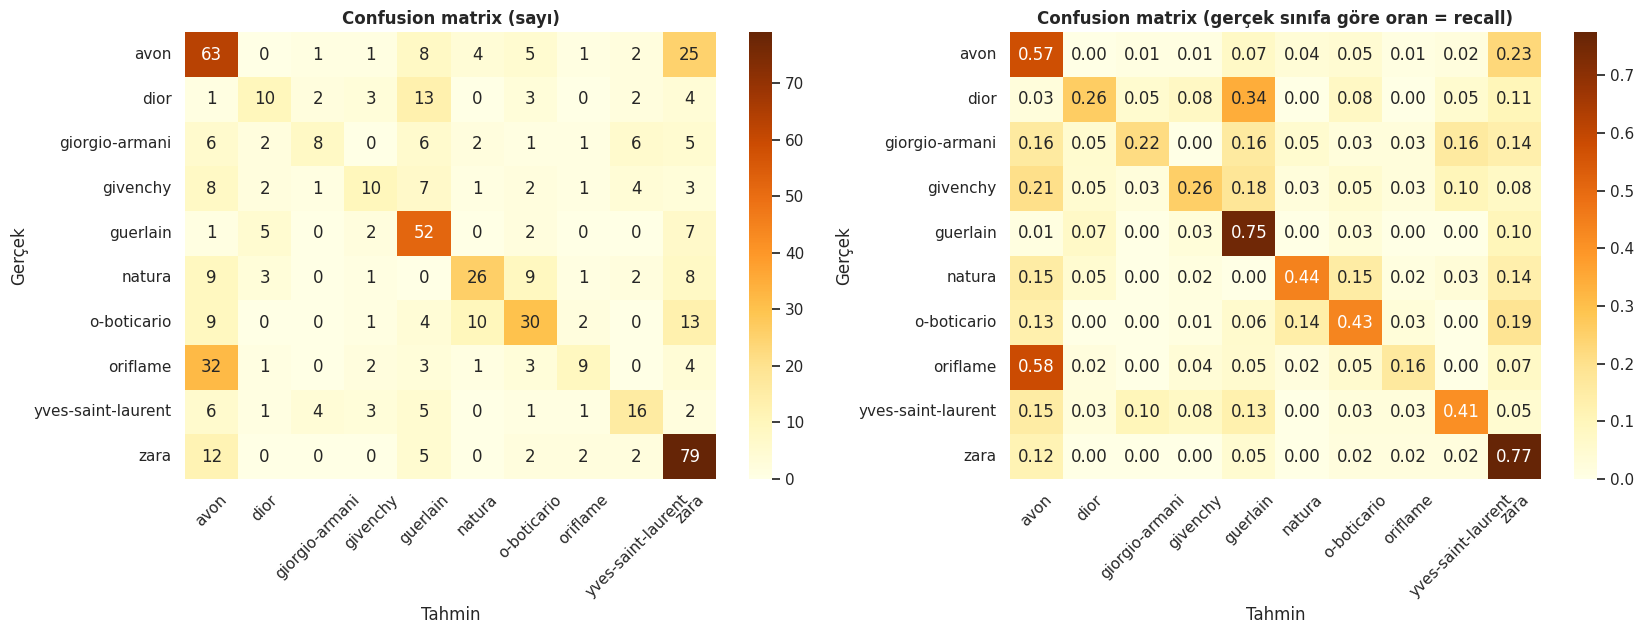

In [12]:
champ_name = results_df.loc[0, "Model"]
champ = best_models[champ_name]
y_pred = champ.predict(X_test)
print(f"Şampiyon model (CV makro-F1'e göre): {champ_name}\n")
print(classification_report(y_test, y_pred))

labels = champ.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr", xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Confusion matrix (sayı)", fontweight="bold")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="YlOrBr", xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Confusion matrix (gerçek sınıfa göre oran = recall)", fontweight="bold")
for ax in axes:
    ax.set_xlabel("Tahmin")
    ax.set_ylabel("Gerçek")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 7. Ablation: yalnızca koku notaları

`Rating Value`, `Rating Count` ve `Year`, markayı tahmin etmek için "doğal" özellikler değildir; markaya özgü yıl veya popülerlik örüntülerini yakalıyor olabilirler. Şampiyon modelin aynı hiperparametreleriyle yalnızca metin (koku notaları) kullanıldığında performansın ne kadar değiştiği ölçülür.

In [13]:
ablation = make_pipeline(clone(champ.named_steps["clf"]), use_meta=False, memory=cache_dir)
ablation.fit(X_train, y_train)
pred_abl = ablation.predict(X_test)

ablation_df = pd.DataFrame([
    {"Özellik seti": "Notlar + cinsiyet + puan + yıl",
     "Test doğruluğu": accuracy_score(y_test, y_pred),
     "Test makro-F1": f1_score(y_test, y_pred, average="macro")},
    {"Özellik seti": "Yalnızca koku notaları",
     "Test doğruluğu": accuracy_score(y_test, pred_abl),
     "Test makro-F1": f1_score(y_test, pred_abl, average="macro")},
]).round(3)
display(ablation_df)

,Özellik seti,Test doğruluğu,Test makro-F1
0,Notlar + cinsiyet + puan + yıl,0.491,0.433
1,Yalnızca koku notaları,0.407,0.353


**Yorum.** Tablodaki fark, puan, popülerlik, yıl ve cinsiyet özelliklerinin doğruluğa belirgin katkı yaptığını gösterir. Yani model yalnızca "koku imzası" öğrenmiyor; markaların puan ve çıkış yılı örüntülerinden de yararlanıyor. Yalnızca notalarla elde edilen sonuç, koku içeriğinin tek başına markayı ne kadar ele verdiğinin daha saf bir ölçüsüdür ve hâlâ rastgele tahminin ve çoğunluk baseline'ının üzerindedir.

## 8. Ek deneyler: metin temsili ve gradient boosting

İki fikir aynı bölme, aynı pipeline ve aynı CV protokolüyle sınandı (kod: `extra_experiments.py`):

- **Metin temsili:** varsayılan kelime n-gram'ları (1–2) yerine, virgülle ayrılmış her notayı tek bir birim sayan özel tokenizer (`lily-of-the-valley` parçalanmaz).
- **Model:** `HistGradientBoostingClassifier` (`class_weight="balanced"`).

| Metin temsili | Model | CV makro-F1 | Test doğruluğu | Test makro-F1 |
|---|---|---|---|---|
| Kelime n-gram | Random Forest | 0.408 | 0.486 | 0.434 |
| Kelime n-gram | Gradient Boosting | 0.417 | 0.452 | 0.406 |
| Nota birimi | Random Forest | 0.406 | 0.465 | 0.390 |
| Nota birimi | Gradient Boosting | 0.402 | 0.476 | 0.426 |
| Nota birimi | Logistic Regression | 0.333 | 0.376 | 0.344 |
| Nota birimi | k-NN | 0.304 | 0.318 | 0.286 |

**Yorum.** Hiçbir varyant diğerlerinden anlamlı biçimde iyi değil: CV makro-F1 değerleri 0.40–0.42 bandında kalıyor ve test sonuçları değişkenlere göre iki yöne de oynuyor (617 örnekte test doğruluğunun belirsizliği yaklaşık ±4 puan). Özel tokenizer ve gradient boosting bu veride gözle görülür bir kazanç sağlamadı. Bu, performans tavanının tokenizer veya model ailesinden çok verinin kendisinden (markaların benzer koku profillerini paylaşması) kaynaklandığına işaret ediyor. Bu nedenle ana modelleme bölümü sade tutuldu. (Bu bölümdeki Random Forest satırı, ana bölümdeki Random Forest'tan pipeline'a eklenen yoğunlaştırma adımı nedeniyle ±0.005 farklı çıkabilir.)


## 9. Sonuçlar ve sınırlılıklar

In [14]:
n_test = len(y_test)
print(f"Şampiyon model: {champ_name}")
print(f"  CV makro-F1      : {results_df.loc[0, 'CV makro-F1']:.3f}")
print(f"  Test doğruluğu   : {results_df.loc[0, 'Test doğruluğu']:.3f}  (baseline {base_acc:.3f}, rastgele {1 / TOP_N_BRANDS:.2f})")
print(f"  Test makro-F1    : {results_df.loc[0, 'Test makro-F1']:.3f}")
print(f"  Yalnızca notalarla doğruluk: {ablation_df.loc[1, 'Test doğruluğu']:.3f}")
print(f"  Test örnek sayısı: {n_test}")

Şampiyon model: Random Forest
  CV makro-F1      : 0.408
  Test doğruluğu   : 0.491  (baseline 0.178, rastgele 0.10)
  Test makro-F1    : 0.433
  Yalnızca notalarla doğruluk: 0.407
  Test örnek sayısı: 617


**Sınırlılıklar**

- Test seti küçük (yaklaşık 600 örnek) ve tek bir bölmeye dayanıyor; sonuçların güven aralığı geniştir. Tekrarlı CV veya birden fazla rastgele bölme daha sağlam bir tahmin verir.
- Analiz yalnızca en popüler 10 markayı kapsar; sonuçlar diğer markalara genellenemez. Sınıflar dengesizdir, bu nedenle makro-F1 ve sınıf bazlı recall, doğruluktan daha bilgilendiricidir.
- Bazı markalar (ör. Avon, Oriflame) benzer koku profillerini paylaştığı için model onları sık karıştırır (confusion matrix'e bakınız).
- `Rating` ve `Year` özellikleri markaya özgü örüntüler taşıyabilir; ablation bölümü bunun etkisini ölçmeye yöneliktir.
- Notalar Fragrantica'nın kullanıcı katkılı verisine dayanır; yazım ve ayrıntı düzeyi tutarsız olabilir.
- Metin özellikleri varsayılan `TfidfVectorizer` tokenizer'ıyla üretildi; çok kelimeli notalar parçalanıyor. Notaları virgülle ayrılmış birimler olarak ele alan bir tokenizer ve gradient boosting denendi, anlamlı bir iyileşme getirmedi (Bölüm 8).
- Hiperparametre ızgarası küçük tutulmuştur; daha geniş bir arama veya TF-IDF yerine gömme (embedding) tabanlı bir temsil hâlâ denenmemiş seçeneklerdir.